<a href="https://colab.research.google.com/github/si-janenunes/CURSO-IA-CETAM-2026/blob/main/18_09_ModuloII_Atividade_REDE_NEURAL_COM_EARLY_STOPPING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importar as bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
#Carregar DataSet

dados = load_wine()
X = dados.data
y = dados.target
print("Quantidade de amostras:", X.shape[0])
print("Quantidade de características:", X.shape[1])
print("Classes:", dados.target_names)

Quantidade de amostras: 178
Quantidade de características: 13
Classes: ['class_0' 'class_1' 'class_2']


In [3]:
#Transformar em DataFrame

df = pd.DataFrame(X, columns=dados.feature_names)
df["classe"] = y
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,classe
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
#Verificar os dados

print(df.shape)
print("\nValores ausentes:\n")
print(df.isnull().sum())
print("\nDistribuição das classes:\n")
print(df["classe"].value_counts())

(178, 14)

Valores ausentes:

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
classe                          0
dtype: int64

Distribuição das classes:

classe
1    71
0    59
2    48
Name: count, dtype: int64


In [5]:
#Separar TESTE

X_train_val, X_test, y_train_val, y_test = train_test_split(
X,
y,
test_size=0.20, #Reservamos 20% para teste.
random_state=42, #Use uma sequência aleatória, mas sempre reproduza a mesma sequência
stratify=y
)

In [6]:
#Separar TRAIN e VALIDATION

X_train, X_val, y_train, y_val = train_test_split(
X_train_val,
y_train_val,
test_size=0.20,
random_state=42, #Para garantir a reprodutibilidade dos resultados.
stratify=y_train_val
)

In [7]:
#conferindo

print("Train: ", X_train.shape)
print("Validation: ", X_val.shape)
print("Test: ", X_test.shape)

Train:  (113, 13)
Validation:  (29, 13)
Test:  (36, 13)


In [8]:
#Normalização

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [9]:
model = keras.Sequential([
layers.Input(shape=(13,)),
layers.Dense(128, activation="relu"),
layers.Dense(64, activation="relu"),
layers.Dense(32, activation="relu"),
layers.Dense(3, activation="softmax")
])

In [10]:
model.compile(
optimizer="adam", #ajusta os pesos
loss="sparse_categorical_crossentropy", # mede o erro para multiclasse
metrics=["accuracy"] # mede a porcentagem de acertos
)
history = model.fit( #guarda o resultado dos valores
X_train,
y_train,
validation_data=(X_val, y_val),
epochs=200,
batch_size=16
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.3274 - loss: 1.0728 - val_accuracy: 0.7241 - val_loss: 0.9006
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8319 - loss: 0.8045 - val_accuracy: 0.8966 - val_loss: 0.7085
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9646 - loss: 0.6052 - val_accuracy: 0.9655 - val_loss: 0.5332
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9912 - loss: 0.4290 - val_accuracy: 0.9310 - val_loss: 0.3842
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9912 - loss: 0.2843 - val_accuracy: 0.9310 - val_loss: 0.2898
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9912 - loss: 0.1833 - val_accuracy: 0.9655 - val_loss: 0.2277
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9912 - loss: 0.1170 - val_accuracy: 0.9655 - val_loss: 0.1901
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.9912 - loss: 0.0733 - val_accuracy: 0.9655 - val_loss

In [11]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


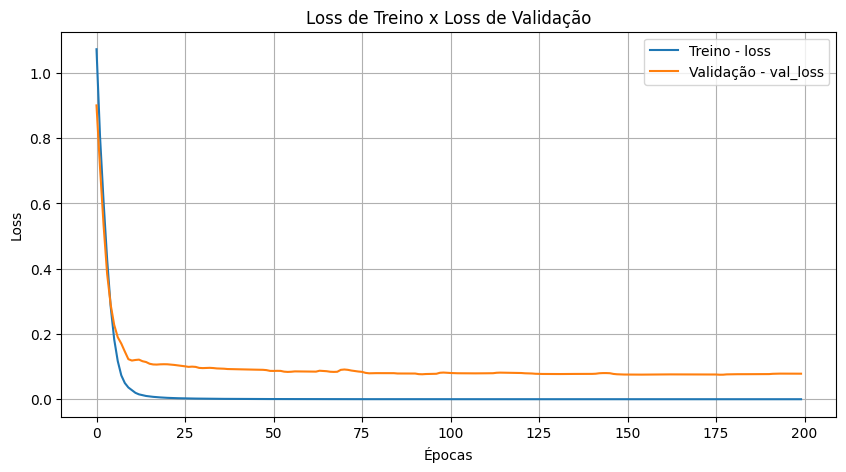

In [12]:
#Gráfico loss × val_loss

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Treino - loss')
plt.plot(history.history['val_loss'], label='Validação - val_loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Loss de Treino x Loss de Validação')
plt.legend()
plt.grid()
plt.show()

In [13]:
#Descobrir automaticamente a melhor época

import numpy as np
melhor_epoca = np.argmin(history.history["val_loss"]) + 1
menor_val_loss = np.min(history.history["val_loss"])
print("Melhor época:", melhor_epoca)
print("Menor val_loss:", menor_val_loss)

Melhor época: 177
Menor val_loss: 0.07510886341333389


In [14]:
restore_best_weights=True

In [15]:
#Criando uma nova rede neural

model_early = keras.Sequential([
# A rede recebe as 13 características do dataset

layers.Input(shape=(13,)),
# Primeira camada oculta

layers.Dense(128, activation="relu"),
# Segunda camada oculta

layers.Dense(64, activation="relu"),

    # Terceira camada oculta
layers.Dense(32, activation="relu"),
# Camada de saída

# Softmax porque temos classificação multiclasse (3 classes)
layers.Dense(3, activation="softmax")
])
model_early.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,227 (47.76 KB)

 Trainable params: 12,227 (47.76 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Compilando a Rede Neural

model_early.compile(
# Algoritmo que ajustará os pesos
optimizer="adam",

# Função de erro para classificação multiclasse com rótulos inteiros

loss="sparse_categorical_crossentropy",
# Métrica que também queremos acompanhar

metrics=["accuracy"]
)

In [17]:
# Criando o Early Stopping

early_stop = keras.callbacks.EarlyStopping(
# Observe o erro da VALIDAÇÃO

monitor="val_loss",

# Aguarde 5 épocas sem melhora
patience=5,

# Ao terminar, volte para os melhores pesos encontrados
restore_best_weights=True
)

In [18]:
# Treinando a nova Rede Neural

history_early = model_early.fit(
# Dados utilizados para APRENDER

X_train,
y_train,

# Dados utilizados para acompanhar a generalização
validation_data=(X_val, y_val),

  # Número MÁXIMO de épocas
epochs=200,

# Quantidade de exemplos processados antes
# de uma atualização dos pesos

batch_size=16,

# Aqui ativamos o Early Stopping que irá acompanhar o treinamento
callbacks=[early_stop]
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.6460 - loss: 0.9574 - val_accuracy: 0.9310 - val_loss: 0.7824
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9558 - loss: 0.6566 - val_accuracy: 0.9310 - val_loss: 0.5359
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9912 - loss: 0.4363 - val_accuracy: 0.9655 - val_loss: 0.3571
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9912 - loss: 0.2792 - val_accuracy: 0.9655 - val_loss: 0.2207
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9912 - loss: 0.1682 - val_accuracy: 1.0000 - val_loss: 0.1341
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9912 - loss: 0.1017 - val_accuracy: 1.0000 - val_loss: 0.0884
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9912 - loss: 0.0665 - val_accuracy: 1.0000 - val_loss: 0.0618
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9912 - loss: 0.0455 - val_accuracy: 0.9655 - val_loss:

In [19]:
# Descobrindo quantas épocas realmente foram executadas

epocas_executadas = len(history_early.history["loss"])
print("Máximo permitido: 200 épocas")

print("Épocas realmente executadas:", epocas_executadas)

Máximo permitido: 200 épocas
Épocas realmente executadas: 35


In [20]:
# Localiza o menor val_loss

melhor_epoca = np.argmin(history_early.history["val_loss"]) + 1

# Recupera o valor do menor val_loss
menor_val_loss = np.min(history_early.history["val_loss"])

print("Melhor época: ", melhor_epoca)
print("Menor val_loss: ", menor_val_loss)

Melhor época:  30
Menor val_loss:  0.012774690054357052


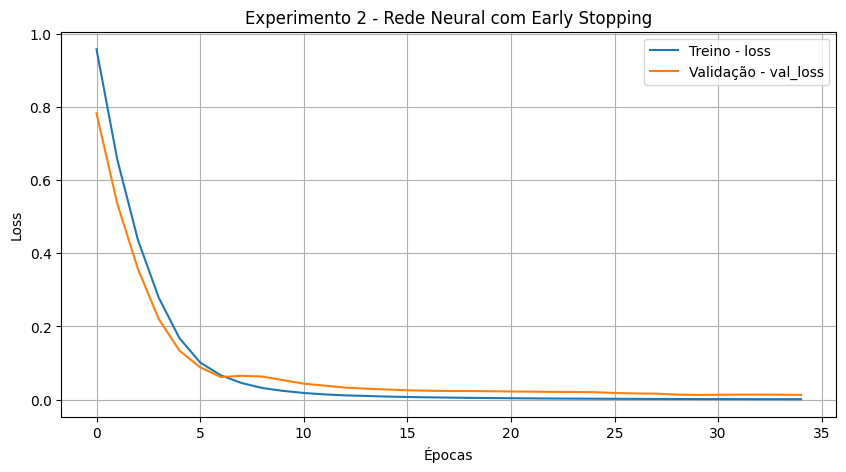

In [21]:
# Gráfico Experimento 2 - Rede Neural com Early Stopping

plt.figure(figsize=(10, 5))
plt.plot(
history_early.history["loss"],
label="Treino - loss"
)
plt.plot(
history_early.history["val_loss"],
label="Validação - val_loss"
)
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title(
"Experimento 2 - Rede Neural com Early Stopping"
)
plt.legend()
plt.grid()
plt.show()

In [22]:
# Avaliação final com dados de TESTE

test_loss, test_accuracy = model_early.evaluate(
X_test,
y_test,
verbose=0
)
print("Loss no teste: ", test_loss)
print("Accuracy no teste: ", test_accuracy)

Loss no teste:  0.09744486957788467
Accuracy no teste:  0.9722222089767456


In [23]:
#Importar o regularizador L2

from tensorflow.keras.regularizers import l2

In [24]:
#Criar uma NOVA rede

model_l2 = keras.Sequential([
# 13 características de entrada

layers.Input(shape=(13,)),
# L2 aplicado aos pesos desta camada

layers.Dense(
128,
activation="relu",
kernel_regularizer=l2(0.001)
),

# L2 aplicado aos pesos desta camada
layers.Dense(
64,
activation="relu",
kernel_regularizer=l2(0.001)
),
# L2 aplicado aos pesos desta camada
layers.Dense(
32,
activation="relu",
kernel_regularizer=l2(0.001)
),
# Saída multiclasse (3 classes) com softmax
layers.Dense(
3,
activation="softmax")
])
model_l2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,227 (47.76 KB)

 Trainable params: 12,227 (47.76 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
kernel_regularizer=l2(0.001) ## L2: penaliza pesos grandes; 0.001 define a
#  intensidade dessa penalização

In [26]:
#Compilar

model_l2.compile(
optimizer="adam",
loss="sparse_categorical_crossentropy",
metrics=["accuracy"]
)

In [27]:
# Treinar 200 epocas

history_l2 = model_l2.fit(
X_train,
y_train,
validation_data=(X_val, y_val),
epochs=200,
batch_size=16
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.4425 - loss: 1.0883 - val_accuracy: 0.6207 - val_loss: 0.9188
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9292 - loss: 0.7657 - val_accuracy: 0.8966 - val_loss: 0.6738
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9912 - loss: 0.5337 - val_accuracy: 0.9655 - val_loss: 0.4844
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9912 - loss: 0.3748 - val_accuracy: 0.9655 - val_loss: 0.3630
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9912 - loss: 0.2801 - val_accuracy: 0.9655 - val_loss: 0.3034
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9912 - loss: 0.2276 - val_accuracy: 0.9655 - val_loss: 0.2793
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9912 - loss: 0.1988 - val_accuracy: 0.9655 - val_loss: 0.2627
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9912 - loss: 0.1833 - val_accuracy: 0.9655 - val_loss:

In [28]:
#Encontrar a melhor epoca

melhor_epoca_l2 = np.argmin(
history_l2.history["val_loss"]
) + 1
menor_val_loss_l2 = np.min(
history_l2.history["val_loss"]
)
print("Melhor época: ", melhor_epoca_l2)
print("Menor val_loss: ", menor_val_loss_l2)

Melhor época:  197
Menor val_loss:  0.041357070207595825


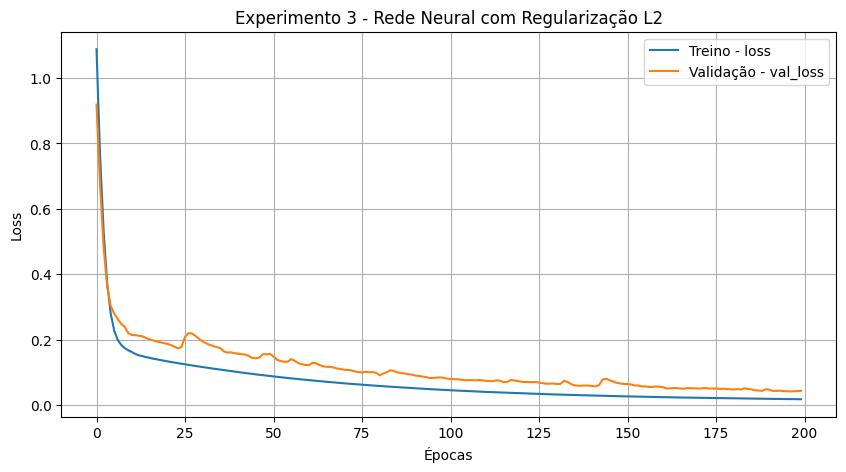

In [29]:
#Grafico Experimento 3 - Rede Neural com Regularização L2

plt.figure(figsize=(10, 5))
plt.plot(
history_l2.history["loss"],
label="Treino - loss"
)
plt.plot(
history_l2.history["val_loss"],
label="Validação - val_loss"
)
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title(

"Experimento 3 - Rede Neural com Regularização L2"
)
plt.legend()
plt.grid()
plt.show()

In [30]:
#Teste

test_loss_l2, test_accuracy_l2 = model_l2.evaluate(
X_test,
y_test,
verbose=0
)
print("Loss no teste: ", test_loss_l2)
print("Accuracy no teste: ", test_accuracy_l2)

Loss no teste:  0.07863340526819229
Accuracy no teste:  0.9722222089767456


In [31]:
model_dropout = keras.Sequential([
    layers.Input(shape=(13,)), # Corrigido para 13 características
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(32, activation="relu"),
    layers.Dense(3, activation="softmax") # Corrigido para 3 classes e ativação softmax
])
model_dropout.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,227 (47.76 KB)

 Trainable params: 12,227 (47.76 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# ============================================================
# COMPILAÇÃO DO MODELO
# ============================================================
model_dropout.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy", # Corrigido para classificação multiclasse
    metrics=["accuracy"]
)

In [33]:
# ============================================================
# TREINAMENTO
# ============================================================

history_dropout = model_dropout.fit(
# X_train contém as características utilizadas
# para o treinamento da rede.

X_train,
# y_train contém as respostas corretas
# correspondentes ao X_train.

y_train,
# A cada época, o Keras também avaliará
# o modelo utilizando os dados de VALIDAÇÃO.
#
# Esses dados NÃO são utilizados para ajustar
# diretamente os pesos.

validation_data=(X_val, y_val),
# Permitimos que a rede treine durante
# 200 épocas completas.

epochs=200,
# A rede processará 16 amostras antes
# de realizar uma atualização dos pesos.

batch_size=16
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.3540 - loss: 1.0697 - val_accuracy: 0.6897 - val_loss: 0.9141
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8053 - loss: 0.7876 - val_accuracy: 0.8276 - val_loss: 0.7171
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8761 - loss: 0.6487 - val_accuracy: 0.9655 - val_loss: 0.5258
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9469 - loss: 0.4939 - val_accuracy: 0.9655 - val_loss: 0.3647
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9646 - loss: 0.3538 - val_accuracy: 0.9655 - val_loss: 0.2381
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9823 - loss: 0.1981 - val_accuracy: 1.0000 - val_loss: 0.1552
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.1512 - val_accuracy: 1.0000 - val_loss: 0.1120
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9912 - loss: 0.1161 - val_accuracy: 1.0000 - val_loss:

In [34]:
print(history_dropout.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


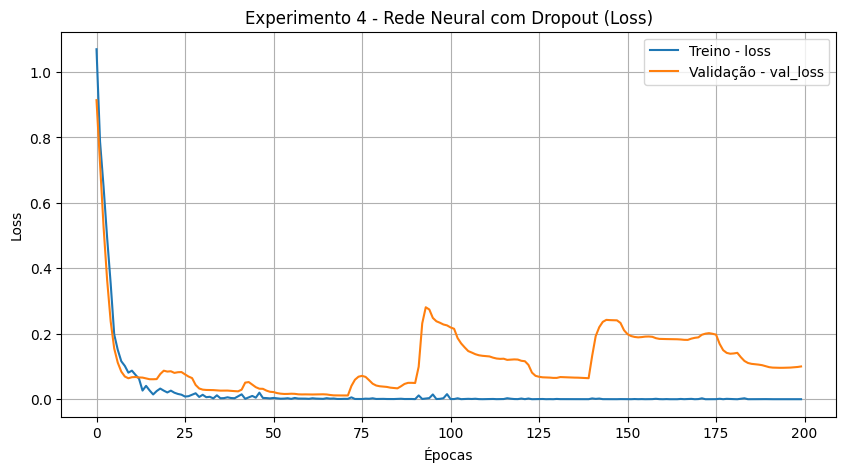

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(history_dropout.history['loss'], label='Treino - loss')
plt.plot(history_dropout.history['val_loss'], label='Validação - val_loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Experimento 4 - Rede Neural com Dropout (Loss)')
plt.legend()
plt.grid()
plt.show()

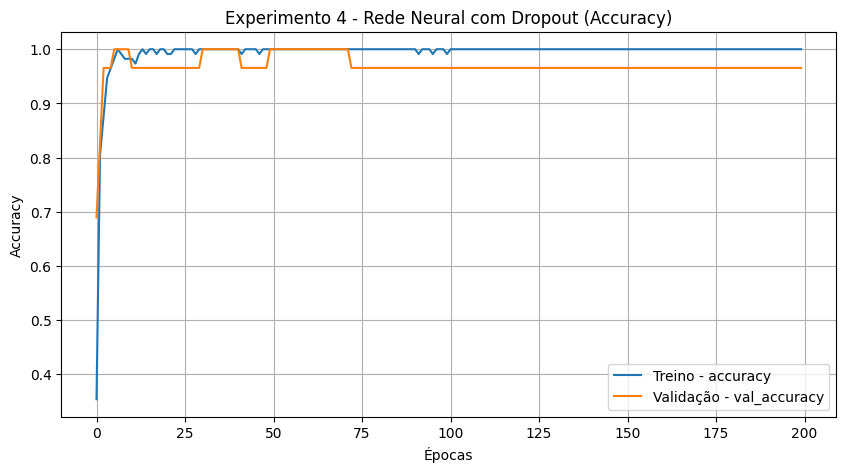

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(history_dropout.history['accuracy'], label='Treino - accuracy')
plt.plot(history_dropout.history['val_accuracy'], label='Validação - val_accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.title('Experimento 4 - Rede Neural com Dropout (Accuracy)')
plt.legend()
plt.grid()
plt.show()

In [37]:
# ============================================================
# QUANTIDADE DE ÉPOCAS EXECUTADAS
# ============================================================

# history_dropout.history[&#39;loss&#39;] contém um valor
# de loss para cada época executada.

# len() conta quantos valores existem nessa lista.

epocas_executadas_dropout = len(
history_dropout.history["loss"]
)
print(
"Épocas executadas: ",
epocas_executadas_dropout
)

Épocas executadas:  200


In [38]:
# ============================================================
# LOCALIZAR A MELHOR ÉPOCA
# ============================================================

# np.argmin() procura a POSIÇÃO onde ocorreu
# o menor valor de val_loss.

# Somamos +1 porque o Python começa a contar
# as posições a partir de zero.

melhor_epoca_dropout = (
np.argmin(history_dropout.history["val_loss"]) + 1
)
# np.min() recupera diretamente o MENOR
# valor encontrado em val_loss.

menor_val_loss_dropout = np.min(
history_dropout.history["val_loss"]
)
print(
"Melhor época: ",
melhor_epoca_dropout
)
print(
"Menor val_loss: ",
menor_val_loss_dropout
)

Melhor época:  72
Menor val_loss:  0.011489280499517918


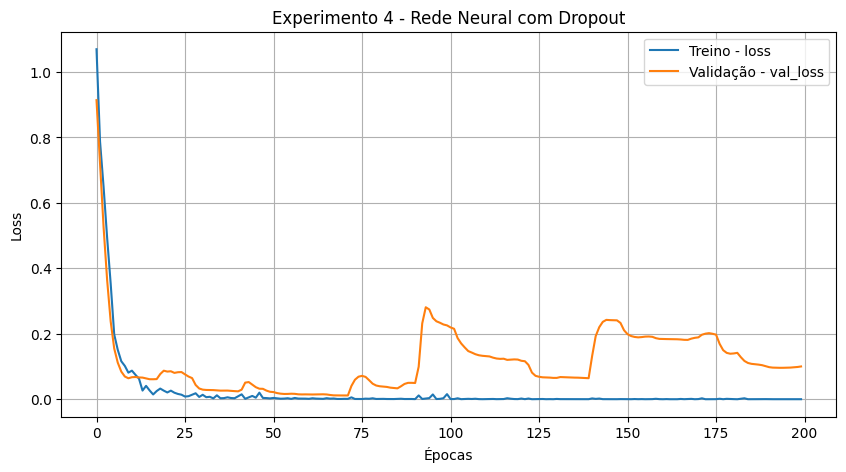

In [39]:
# ============================================================
# GRÁFICO DO TREINAMENTO
# ============================================================

# Criamos uma figura com tamanho 10 x 5.
plt.figure(figsize=(10, 5))

# Linha do LOSS de treinamento.

# Cada posição da lista representa uma época.
plt.plot(
history_dropout.history["loss"],
label="Treino - loss"
)

# Linha do LOSS de validação.

# É esta curva que utilizamos para acompanhar
# a capacidade de generalização.

plt.plot(
history_dropout.history["val_loss"],
label="Validação - val_loss"
)

# Nome do eixo horizontal.
plt.xlabel("Épocas")
# Nome do eixo vertical.
plt.ylabel("Loss")

# Título do gráfico.
plt.title(
"Experimento 4 - Rede Neural com Dropout"
)

# Mostra a legenda das duas curvas.
plt.legend()

# Adiciona linhas de grade para facilitar
# a leitura do gráfico.
plt.grid()
# Exibe o gráfico.
plt.show()

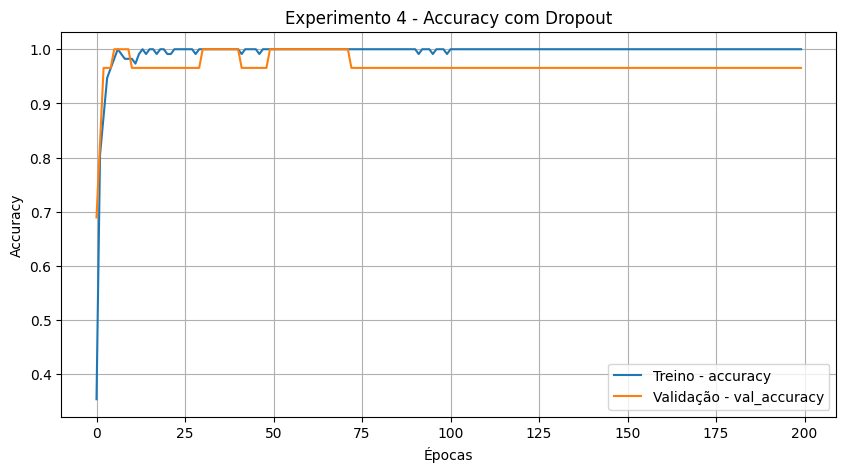

In [40]:
# ============================================================
# GRÁFICO DE ACCURACY
# ============================================================

plt.figure(figsize=(10, 5))
# Accuracy nos dados utilizados para treinamento.

plt.plot(
history_dropout.history["accuracy"],
label="Treino - accuracy"
)

# Accuracy nos dados de validação.
plt.plot(
history_dropout.history["val_accuracy"],
label="Validação - val_accuracy"
)

plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title(
"Experimento 4 - Accuracy com Dropout"
)
plt.legend()
plt.grid()
plt.show()

In [41]:
# ============================================================
# AVALIAÇÃO FINAL NO CONJUNTO DE TESTE
# ============================================================

# evaluate() apresenta ao modelo dados que ficaram
# separados do treinamento.

# X_test = características
# y_test = respostas corretas

test_loss_dropout, test_accuracy_dropout = (
model_dropout.evaluate(
X_test,
y_test,

# verbose=0 evita imprimir a barra
# de progresso da avaliação.

verbose=0
)
)
print(
"Loss no teste: ",
test_loss_dropout
)
print(
"Accuracy no teste: ",
test_accuracy_dropout
)

Loss no teste:  0.0061059813015162945
Accuracy no teste:  1.0


In [42]:
# ============================================================
# EXPERIMENTO 5
# L2 + DROPOUT + EARLY STOPPING
# ============================================================

# Criamos uma NOVA rede neural.
# Ela começará novamente com novos pesos.

model_final = keras.Sequential([
# Entrada:
# nosso dataset possui 13 características.

layers.Input(shape=(13,)),

# --------------------------------------------------------
# PRIMEIRA CAMADA OCULTA
# --------------------------------------------------------

# 128 neurônios com função de ativação ReLU.

# kernel_regularizer=l2(0.001)
# aplica regularização L2 aos pesos desta camada.

layers.Dense(
128,
activation="relu",
kernel_regularizer=l2(0.001)
),
# Durante o treinamento, 30% das ativações
# serão zeradas aleatoriamente.
layers.Dropout(0.30),

# --------------------------------------------------------
# SEGUNDA CAMADA OCULTA
# --------------------------------------------------------

layers.Dense(
64,
activation="relu",
kernel_regularizer=l2(0.001)
),
# Novamente aplicamos Dropout de 30%.
layers.Dropout(0.30),

# --------------------------------------------------------
# TERCEIRA CAMADA OCULTA
# --------------------------------------------------------
layers.Dense(
32,
activation="relu",
kernel_regularizer=l2(0.001)
),

# --------------------------------------------------------
# CAMADA DE SAÍDA
# --------------------------------------------------------

# Um neurônio com Sigmoid porque estamos
# fazendo classificação binária.

layers.Dense(
1,
activation="sigmoid"
)
])
# Exibe a arquitetura da rede.

model_final.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# ============================================================
# EARLY STOPPING
# ============================================================

early_stop_final = keras.callbacks.EarlyStopping(

# Acompanhar o erro nos dados de validação.

monitor="val_loss",
# Queremos que val_loss DIMINUA.

mode="min",
# Aguarda 5 épocas consecutivas sem uma nova melhora.

patience=5,
# Ao parar, recupera os pesos correspondentes
# ao melhor val_loss encontrado.

restore_best_weights=True
)

In [44]:
# ============================================================
# TREINAMENTO
# ============================================================

# Compilando o modelo
model_final.compile(
optimizer="adam",
loss="binary_crossentropy",
metrics=["accuracy"]
)
history_final = model_final.fit(
# Dados utilizados para aprender.

X_train,
y_train,

# Dados utilizados para acompanhar
# a capacidade de generalização.

validation_data=(X_val, y_val),
# Número MÁXIMO de épocas.

epochs=200,
# Processa 16 amostras antes
# de atualizar os pesos.

batch_size=16,
# Ativa o Early Stopping.
callbacks=[early_stop_final]
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.3894 - loss: 0.9967 - val_accuracy: 0.5517 - val_loss: 0.7899
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5575 - loss: 0.7199 - val_accuracy: 0.6207 - val_loss: 0.6012
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6814 - loss: 0.5146 - val_accuracy: 0.6897 - val_loss: 0.3750
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6991 - loss: 0.2742 - val_accuracy: 0.7241 - val_loss: 0.0603
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6991 - loss: -0.0907 - val_accuracy: 0.7241 - val_loss: -0.3447
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6991 - loss: -0.5036 - val_accuracy: 0.7241 - val_loss: -0.8979
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7168 - loss: -1.2168 - val_accuracy: 0.6897 - val_loss: -1.7167
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7168 - loss: -2.0984 - val_accuracy: 0.6897 - va

In [45]:
# ============================================================
# QUANTIDADE DE ÉPOCAS EXECUTADAS
# ============================================================

epocas_final = len(
history_final.history["loss"]
)
print("Máximo permitido: 200")
print("Épocas realmente executadas: ", epocas_final)

Máximo permitido: 200
Épocas realmente executadas:  200


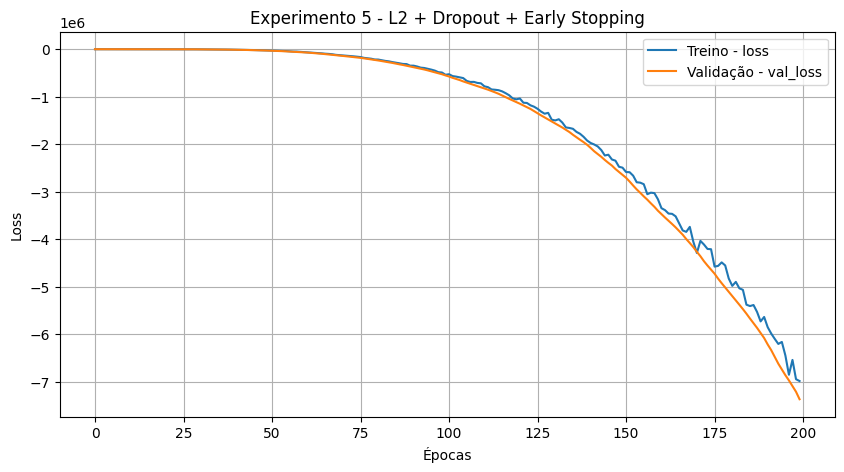

In [46]:
# ============================================================
# GRÁFICO LOSS x VAL_LOSS
# ============================================================

plt.figure(figsize=(10, 5))
# Erro nos dados de treinamento.

plt.plot(
history_final.history["loss"],
label="Treino - loss"
)

# Erro nos dados de validação.

plt.plot(
history_final.history["val_loss"],
label="Validação - val_loss"
)
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title(
"Experimento 5 - L2 + Dropout + Early Stopping"
)
plt.legend()
plt.grid()
plt.show()

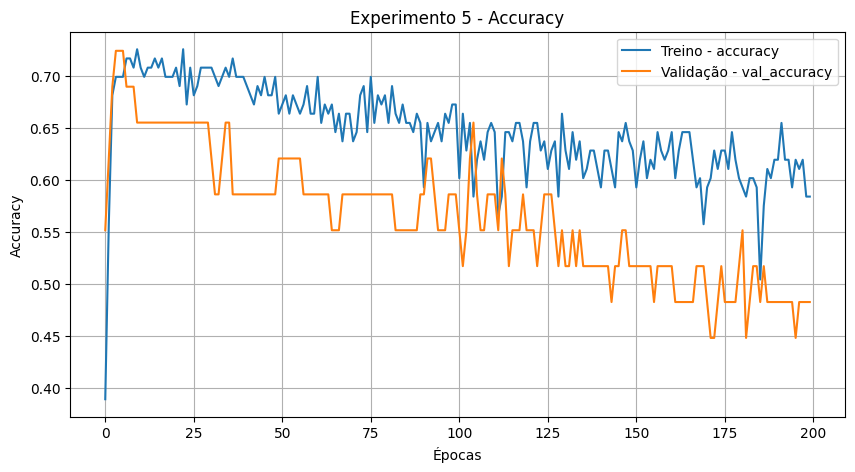

In [47]:
# ============================================================
# GRÁFICO DA ACCURACY
# ============================================================

plt.figure(figsize=(10, 5))
# Accuracy no treinamento.

plt.plot(
history_final.history["accuracy"],
label="Treino - accuracy"
)
# Accuracy na validação.

plt.plot(
history_final.history["val_accuracy"],
label="Validação - val_accuracy"
)
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title(
"Experimento 5 - Accuracy"
)
plt.legend()
plt.grid()
plt.show()

In [48]:
# ============================================================
# AVALIAÇÃO FINAL NO TESTe
# ============================================================

test_loss_final, test_accuracy_final = (
model_final.evaluate(
X_test,
y_test,
verbose=0
)
)
print("Loss no teste: ", test_loss_final)
print(
"Accuracy no teste: ",
test_accuracy_final
)
print(
"Accuracy no teste (%): ",
test_accuracy_final * 100
)

Loss no teste:  -7283986.5
Accuracy no teste:  0.6388888955116272
Accuracy no teste (%):  63.88888955116272


In [49]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2

# ============================================================
# FUNÇÃO PARA CRIAR A REDE NEURAL
# ============================================================

def criar_modelo(valor_l2, valor_dropout):
    # Limpa a sessão Keras para evitar conflitos de estado de modelos anteriores
    tf.keras.backend.clear_session()

    # Toda vez que chamarmos esta função,
    # uma NOVA rede neural será criada.

    modelo = keras.Sequential([

        # Corrigido para 13 características de entrada
        layers.Input(shape=(13,)),

        # Primeira camada oculta
        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=l2(valor_l2)
        ),
        # O valor do Dropout agora será variável
        layers.Dropout(valor_dropout),

        # Segunda camada oculta
        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=l2(valor_l2)
        ),
        layers.Dropout(valor_dropout),
        # Terceira camada oculta
        layers.Dense(
            32,
            activation="relu",
            kernel_regularizer=l2(valor_l2)
        ),
        # Saída multiclasse (3 classes) com softmax
        layers.Dense(
            3,
            activation="softmax"
        )
    ])
    # Compilação da nova rede
    modelo.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy", # Corrigido para multiclasse
        metrics=["accuracy"]
    )
    return modelo

In [50]:
# ============================================================
# HIPERPARÂMETROS QUE SERÃO TESTADOS
# ============================================================

configuracoes = [

# L2 Dropout

(0.001, 0.30),
(0.001, 0.15),
(0.0001, 0.30),
(0.0001, 0.15)
]

In [51]:
# Lista vazia onde guardaremos
# o resultado de cada experimento.

resultados_tuning = []

In [52]:
# ============================================================
# TESTE AUTOMÁTICO DOS HIPERPARÂMETROS
# ============================================================

for valor_l2, valor_dropout in configuracoes:
    print("\n======================================")
    print("Testando: ")
    print("L2 = ", valor_l2)
    print("Dropout = ", valor_dropout)
    print("======================================")

    # Cria uma NOVA rede para esta combinação

    modelo_temp = criar_modelo(
        valor_l2,
        valor_dropout
    )

    # Early Stopping NOVO para cada treinamento

    early_stop_temp = keras.callbacks.EarlyStopping(

        # Observa a validação

        monitor="val_loss",

        # Quanto menor, melhor

        mode="min",

        # Espera até 10 épocas sem melhora

        patience=10,

        # Recupera os melhores pesos

        restore_best_weights=True
    )

    # Treina a rede

    history_temp = modelo_temp.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),

        # Máximo de épocas

        epochs=200,
        batch_size=16,
        callbacks=[early_stop_temp],

        # Não mostra todas as épocas na tela
        verbose=0
    )

    # Descobre a melhor época
    melhor_epoca = (
        np.argmin(history_temp.history["val_loss"]) + 1
    )
    # Descobre o menor val_loss
    melhor_val_loss = np.min(
        history_temp.history["val_loss"]
    )
    # Quantas épocas foram realmente executadas?

    epocas_executadas = len(
        history_temp.history["loss"]
    )
    # Guarda os resultados

    resultados_tuning.append({
        "L2": valor_l2,
        "Dropout": valor_dropout,
        "Melhor época": melhor_epoca,
        "Épocas executadas": epocas_executadas,
        "Melhor val_loss": melhor_val_loss
    })


Testando: 
L2 =  0.001
Dropout =  0.3

Testando: 
L2 =  0.001
Dropout =  0.15

Testando: 
L2 =  0.0001
Dropout =  0.3

Testando: 
L2 =  0.0001
Dropout =  0.15


In [53]:
# ============================================================
# TABELA COM OS RESULTADOS
# ============================================================

tabela_tuning = pd.DataFrame(
resultados_tuning
)
tabela_tuning

,L2,Dropout,Melhor época,Épocas executadas,Melhor val_loss
0,0.0010,0.30,37,47,0.142232
1,0.0010,0.15,96,106,0.076733
2,0.0001,0.30,18,28,0.046654
3,0.0001,0.15,15,25,0.056715


In [54]:
# ============================================================
# MELHOR CONFIGURAÇÃO
# ============================================================
melhor_configuracao = tabela_tuning.loc[
tabela_tuning["Melhor val_loss"].idxmin()
]
print("MELHOR CONFIGURAÇÃO")
print()
print(
"L2:",
melhor_configuracao["L2"]
)
print(
"Dropout:",
melhor_configuracao["Dropout"]
)
print(
"Melhor época:",
int(melhor_configuracao["Melhor época"])
)
print(
"Melhor val_loss:",
melhor_configuracao["Melhor val_loss"]
)


MELHOR CONFIGURAÇÃO

L2: 0.0001
Dropout: 0.3
Melhor época: 18
Melhor val_loss: 0.046654053032398224


In [55]:
# ============================================================
# CRIAR O MODELO COM OS MELHORES HIPERPARÂMETROS
# ============================================================

# Valores escolhidos pelo Hyperparameter Tuning
melhor_l2 = 0.0001
melhor_dropout = 0.15
# Criamos uma NOVA rede com a configuração vencedora
modelo_vencedor = criar_modelo(
melhor_l2,
melhor_dropout
)
modelo_vencedor.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,227 (47.76 KB)

 Trainable params: 12,227 (47.76 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# ============================================================
# EARLY STOPPING DO MODELO VENCEDOR
# ============================================================

early_stop_vencedor = keras.callbacks.EarlyStopping(

# Acompanha o erro de validação

monitor="val_loss",

# Queremos minimizar o val_loss

mode="min",

# Espera até 10 épocas sem melhora

patience=10,

# Recupera os pesos da melhor época
restore_best_weights=True
)

In [57]:
# ============================================================
# TREINAMENTO DO MODELO VENCEDOR
# ============================================================

history_vencedor = modelo_vencedor.fit(

# Dados de treinamento
X_train,
y_train,

# Dados de validação
validation_data=(X_val, y_val),

# Limite máximo
epochs=200,

# Tamanho do lote
batch_size=16,

# Early Stopping
callbacks=[early_stop_vencedor]
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.3805 - loss: 1.1114 - val_accuracy: 0.6207 - val_loss: 0.9395
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6195 - loss: 0.8849 - val_accuracy: 0.8276 - val_loss: 0.7757
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8142 - loss: 0.7249 - val_accuracy: 0.8966 - val_loss: 0.6212
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8761 - loss: 0.5763 - val_accuracy: 0.9310 - val_loss: 0.4809
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9646 - loss: 0.4314 - val_accuracy: 0.9310 - val_loss: 0.3601
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9823 - loss: 0.3108 - val_accuracy: 0.9655 - val_loss: 0.2691
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9646 - loss: 0.2282 - val_accuracy: 0.9655 - val_loss: 0.2164
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9823 - loss: 0.1629 - val_accuracy: 0.9655 - val_loss:

In [58]:
# Quantas épocas foram executadas?

epocas_vencedor = len(
history_vencedor.history["loss"]
)
# Qual apresentou o menor val_loss?
melhor_epoca_vencedor = (
np.argmin(history_vencedor.history["val_loss"]) + 1
)
menor_val_loss_vencedor = np.min(
history_vencedor.history["val_loss"]
)
print("Épocas executadas: ", epocas_vencedor)
print("Melhor época: ", melhor_epoca_vencedor)
print("Menor val_loss: ", menor_val_loss_vencedor)

Épocas executadas:  41
Melhor época:  31
Menor val_loss:  0.10148491710424423


# FINAL!!!!!!